In [ ]:
######################################################################
## 05_ANALYSIS: Methylation across gene regions
######################################################################

In [12]:
######################################################################
## 0. Project paths + output folders (relative)
######################################################################
# Expected project structure:
#   data/
#   outputs/figures/

suppressPackageStartupMessages(library(here))

# Resolve project root silently
proj_dir <- here::here()

# Standard folders (relative to project root)
data_dir    <- file.path(proj_dir, "data")
out_fig_dir <- file.path(proj_dir, "outputs", "figures")

dir.create(out_fig_dir, recursive = TRUE, showWarnings = FALSE)

# Input files (relative)
bsseq_file <- file.path(data_dir, "bsseq_snp_masked.RData")
gff_file   <- file.path(data_dir, "GCF_021869535.1_genomic.gff")
salmon_quant_file <- file.path(data_dir, "salmon_quant", "quant.sf")

# Existence checks only (no printing)
stopifnot(
  file.exists(bsseq_file),
  file.exists(gff_file),
  file.exists(salmon_quant_file)
)

In [2]:
######################################################################
## 1. Load libraries
######################################################################

suppressMessages({
  library(bsseq)
  library(GenomicFeatures)
  library(GenomicRanges)
  library(rtracklayer)
  library(GenomicAlignments)
  library(GenomeInfoDb)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(tidyverse)
  library(tximport)
})  

In [3]:
######################################################################
## 2A. Load BSseq object
######################################################################

load("bsseq_snp_masked.RData")
bsseq <- BSseq_obj_masked

In [4]:
######################################################################
## 2B. Load Expression data
######################################################################

# Load GFF
gff <- import(gff_file)

# Load Salmon output
txi <- tximport(salmon_quant_file, type = "salmon", txOut = TRUE)

# Convert to data frame
expression_df <- as.data.frame(txi$abundance) %>%
  rownames_to_column("tx_id") %>%
  pivot_longer(-tx_id, names_to = "sample", values_to = "tpm")

## Extract protein → gene mapping from GFF

gff_df <- as.data.frame(gff)

# Filter for CDS features with both protein_id and gene ID
tx2gene <- gff_df %>%
  filter(type == "CDS" & !is.na(protein_id) & !is.na(gene)) %>%
  select(protein_id, gene_id = gene) %>%
  distinct()

## Merge expression with gene IDs

# Extract protein ID from tx_id in expression data
expression_df <- expression_df %>%
  mutate(protein_id = str_extract(tx_id, "XP_\\d+\\.\\d+"))

# Merge with tx2gene mapping
expression_df <- expression_df %>%
  left_join(tx2gene, by = "protein_id") %>%
  mutate(gene = paste0("gene-", gene_id)) %>%
  filter(!is.na(gene))  # Remove any unmatched IDs

## Summarize gene-level expression

expression_gene <- expression_df %>%
  group_by(gene) %>%
  slice_max(order_by = tpm, n = 1, with_ties = FALSE) %>%  # top protein per gene
  summarise(
    tpm = sum(tpm, na.rm = TRUE),
    protein_id = first(protein_id),
    .groups = "drop"
  )

head(expression_gene)

reading in files with read_tsv

1 




gene,tpm,protein_id
<chr>,<dbl>,<chr>
gene-LOC127698167,0.000000,XP_052080128.1
gene-LOC127698169,0.000000,XP_052057848.1
gene-LOC127698171,0.569278,XP_052057481.1
gene-LOC127698172,146.760455,XP_052057483.1
gene-LOC127698173,3.452572,XP_052057485.1
gene-LOC127698174,0.000000,XP_052057486.1


In [5]:
######################################################################
## 3A. Extracting Gene Models
######################################################################

# Filter for gene features
genes <- gff[gff$type == "gene"]

# Filter to protein-coding genes
genes <- genes[
  !is.na(genes$gene_biotype) &
    genes$gene_biotype %in% c("protein_coding")
]

#  Assign gene_id (required by downstream functions)
genes$gene_id <- genes$Name  # Use Name column (e.g., LOC127xxxxx)

# Sanity check
length(genes)

[1] 26243

In [6]:
######################################################################
## 3B. Make gene_id align with expression_gene$gene
######################################################################

# 1) Build the same "gene-<ID>" strings that expression_gene uses:
genes$gene_id <- paste0("gene-", genes$gene)

# 2) Pull in TPM by matching on that
genes$tpm <- expression_gene$tpm[
  match(genes$gene_id, expression_gene$gene)
]

# 3) Cut into Low/Intermediate/High
genes$expr_cat <- cut(
  genes$tpm,
  breaks = c(-Inf, 1, 10, Inf),
  labels = c("Low", "Intermediate", "High")
)

# 4) Sanity check
table(genes$expr_cat)


         Low Intermediate         High 
       15104         7298         3750 

In [7]:
######################################################################
## 4. Methylation Binning
######################################################################

get_methylation_profile_by_gene <- function(bsseq_obj, gene_ranges, flank_size = 2000, nbins_body = 100, nbins_flank = 20, sample_name = NULL) {
  
  # Helper function: tile a region into n bins
  tile_region <- function(gr, nbins) {
    gr_tiled <- unlist(tile(gr, n = nbins))
    mcols(gr_tiled)$bin_index <- rep(1:nbins, times = length(gr))
    gr_tiled$gene_id <- rep(gr$gene_id, each = nbins)
    gr_tiled$region <- rep(gr$region, each = nbins)
    gr_tiled$gene_strand <- rep(as.character(strand(gr)), each = nbins)
    return(gr_tiled)
  }

  # Ensure gene_id is defined
  if (is.null(gene_ranges$gene_id)) {
    gene_ranges$gene_id <- names(gene_ranges)
  }

  # Define flanking regions and label region types
  upstream <- promoters(gene_ranges, upstream = flank_size, downstream = 0)
  upstream$region <- "upstream"

  downstream <- flank(gene_ranges, width = flank_size, start = FALSE)
  downstream$region <- "downstream"

  gene_body <- gene_ranges
  gene_body$region <- "body"

  # Tile regions
  upstream_tiled <- tile_region(upstream, nbins_flank)
  body_tiled <- tile_region(gene_body, nbins_body)
  downstream_tiled <- tile_region(downstream, nbins_flank)

  all_bins <- c(upstream_tiled, body_tiled, downstream_tiled)

  # Extract methylation values
  meth_matrix <- getMeth(bsseq_obj, regions = all_bins, type = "raw", what = "perRegion")
  
  if (is.null(sample_name)) {
    sample_name <- colnames(meth_matrix)[1]
  }

  # Assemble tidy dataframe
  df <- data.frame(
    gene_id = all_bins$gene_id,
    bin_index = all_bins$bin_index,
    region = all_bins$region,
    gene = all_bins$gene_strand,
    methylation = as.numeric(meth_matrix[, 1]),
    sample = sample_name
  )

  # Flip bins for genes on minus strand
  df <- df %>%
    group_by(gene_id, region) %>%
    mutate(bin_index = if_else(gene == "-", max(bin_index) + 1 - bin_index, bin_index)) %>%
    ungroup()

  # Global bin index for plotting
  df <- df %>%
    mutate(
      bin_global = case_when(
        region == "upstream" ~ bin_index,
        region == "body" ~ bin_index + nbins_flank,
        region == "downstream" ~ bin_index + nbins_flank + nbins_body
      )
    )

  return(df)
}

df_profile <- get_methylation_profile_by_gene(bsseq, genes)

# immediately join back on expr_cat
df_profile <- df_profile %>%
  left_join(
    as.data.frame(mcols(genes))[, c("gene_id","expr_cat")],
    by = "gene_id"
  )

# Check
head(df_profile)
summary(df_profile$methylation)
table(df_profile$region)

# save
saveRDS(df_profile, "df_profile.rds")

gene_id,bin_index,region,gene,methylation,sample,bin_global,expr_cat
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<fct>
gene-LOC127711003,1,upstream,+,NA,M44-9-1yr,1,Low
gene-LOC127711003,2,upstream,+,NaN,M44-9-1yr,2,Low
gene-LOC127711003,3,upstream,+,0.00000000,M44-9-1yr,3,Low
gene-LOC127711003,4,upstream,+,0.05277778,M44-9-1yr,4,Low
gene-LOC127711003,5,upstream,+,0.06097561,M44-9-1yr,5,Low
gene-LOC127711003,6,upstream,+,0.07142857,M44-9-1yr,6,Low


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    0.0     0.0     0.0     0.2     0.5     1.0 1314854 


      body downstream   upstream 
   2624300     524860     524860 

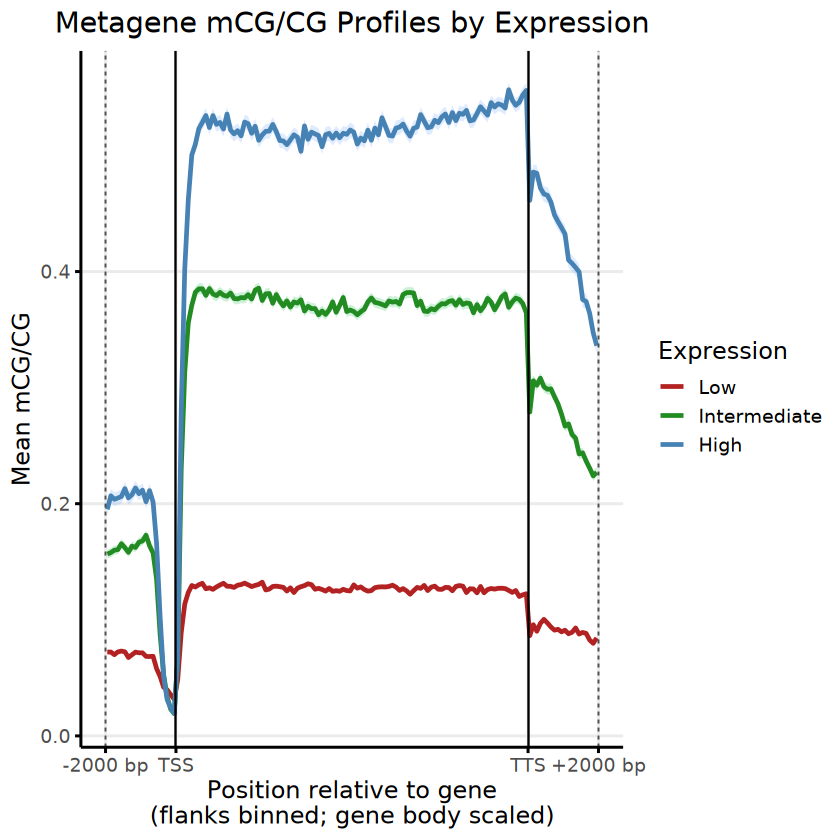

In [8]:
######################################################################
## 5. Stratified metagene profile plot by expression category
######################################################################

library(dplyr)
library(ggplot2)

nbins_flank <- 20
nbins_body  <- 100

# These are just for *labels*
FLANK_BP_LABEL <- 2000  # set to whatever flank bp you actually used (e.g., 2000)
# (Gene body is scaled, so you generally should not label it with bp)

# --- Define bin-axis landmarks (assuming bin_global starts at 1) ---
x_left_edge  <- 0.5
x_TSS        <- nbins_flank + 0.5
x_TTS        <- nbins_flank + nbins_body + 0.5
x_right_edge <- nbins_flank + nbins_body + nbins_flank + 0.5

df_sum <- df_profile %>%
  filter(!is.na(expr_cat), !is.nan(methylation)) %>%
  group_by(expr_cat, bin_global) %>%
  summarise(
    mean_meth = mean(methylation, na.rm = TRUE),
    sem_meth  = sd(methylation, na.rm = TRUE) / sqrt(dplyr::n()),
    .groups   = "drop"
  )

p_metagene <- ggplot(df_sum, aes(x = bin_global, y = mean_meth, color = expr_cat)) +
  geom_ribbon(
    aes(ymin = mean_meth - sem_meth, ymax = mean_meth + sem_meth, fill = expr_cat),
    alpha = 0.2, color = NA, show.legend = FALSE
  ) +
  geom_line(linewidth = 1) +

  # --- Vertical reference lines (ALL in BIN coordinates) ---
  geom_vline(xintercept = c(x_left_edge, x_right_edge),
             linetype = "dashed", linewidth = 0.4, color = "grey30") +
  geom_vline(xintercept = c(x_TSS, x_TTS),
             linetype = "solid", linewidth = 0.5, color = "black") +

  # --- Axis labels to communicate flank extent ---
  scale_x_continuous(
    breaks = c(x_left_edge, x_TSS, x_TTS, x_right_edge),
    labels = c(paste0("-", FLANK_BP_LABEL, " bp"), "TSS", "TTS", paste0("+", FLANK_BP_LABEL, " bp"))
  ) +

  scale_color_manual(
    name   = "Expression",
    values = c("Low"="firebrick", "Intermediate"="forestgreen", "High"="steelblue")
  ) +

  labs(
    title = "Metagene mCG/CG Profiles by Expression",
    x = "Position relative to gene\n(flanks binned; gene body scaled)",
    y     = "Mean mCG/CG"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title       = element_text(hjust = 0.5),
    panel.grid.minor = element_blank(),
    axis.line        = element_line(color="black"),
    axis.ticks       = element_line(color="black")
  )

p_metagene

Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_line()`).”


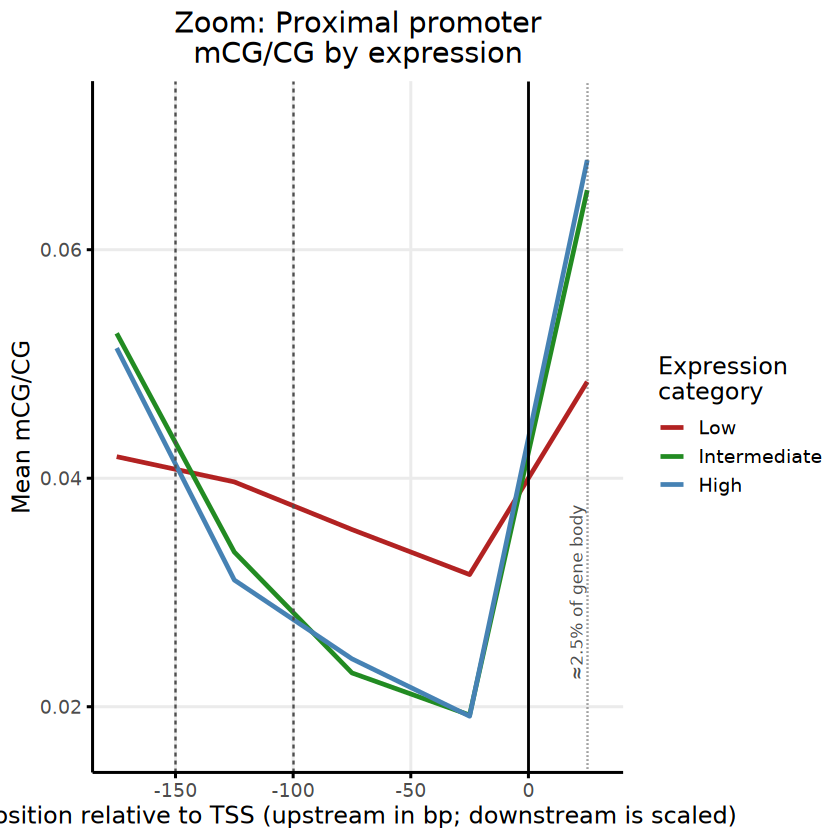

In [9]:
######################################################################
## 6. Zoom on promoter
######################################################################

library(dplyr)
library(ggplot2)

# Parameters — must match BLOCK 4 tiling
flank_size   <- 1000
nbins_flank  <- 20
bin_width    <- flank_size / nbins_flank      # = 50 bp with these values

# Gene body bins in df_profile are length-scaled; we map them onto a 0..body_scale axis
nbins_body   <- 20
body_scale   <- 1000

# We want upstream from -200 bp to 0:
# upstream bin centers are: -flank_size + (bin_index - 0.5) * bin_width
# Solve for center >= -200:
# -1000 + (bin - 0.5)*50 >= -200  ->  (bin - 0.5) >= 16  ->  bin >= 16.5 -> 17
upstream_min_bin <- 17

promoter_zoom_df <- df_profile %>%
  filter(
    !is.na(expr_cat),
    !is.na(methylation),
    (region == "upstream" & bin_index >= upstream_min_bin) |
      (region == "body" & bin_index <= 3)   # first few scaled bins into gene body
  ) %>%
  group_by(expr_cat, region, bin_index) %>%
  summarise(mean_meth = mean(methylation, na.rm = TRUE), .groups = "drop") %>%
  mutate(
    pos = case_when(
      region == "upstream" ~ -flank_size + (bin_index - 0.5) * bin_width,
      region == "body"     ~ (bin_index - 0.5) / nbins_body * body_scale
    )
  )

ggplot(promoter_zoom_df, aes(x = pos, y = mean_meth, color = expr_cat)) +
  geom_line(linewidth = 1) +

  # Reference lines (in the coordinate system of this plot)
  geom_vline(xintercept = -150, linetype = "dashed", linewidth = 0.5, color = "grey30") +
  geom_vline(xintercept = -100, linetype = "dashed", linewidth = 0.5, color = "grey30") +
  geom_vline(xintercept = 0,    linetype = "solid",  linewidth = 0.6, color = "black") +
  geom_vline(xintercept = 25,   linetype = "dotted", linewidth = 0.5, color = "grey30") +

  # Label for scaled gene-body position
  annotate(
    "text",
    x = 25,
    y = 0.03,              # slightly below top of y-range
    label = "≈2.5% of gene body",
    angle = 90,
    vjust = -0.4,
    size = 3.5,
    color = "grey30"
  ) +

  # Actually zoom to the region you're annotating
  coord_cartesian(xlim = c(-175, 30)) +

  scale_y_continuous(limits = c(0.017, 0.072)) +
  scale_color_manual(values = c("Low"="firebrick", "Intermediate"="forestgreen", "High"="steelblue")) +
  labs(
    title = "Zoom: Proximal promoter\nmCG/CG by expression",
    x     = "Position relative to TSS (upstream in bp; downstream is scaled)",
    y     = "Mean mCG/CG",
    color = "Expression\ncategory"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title       = element_text(hjust = 0.5),
    panel.grid.minor = element_blank(),
    axis.line        = element_line(color = "black"),
    axis.ticks       = element_line(color = "black")
  )

Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_line()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range (`geom_line()`).”


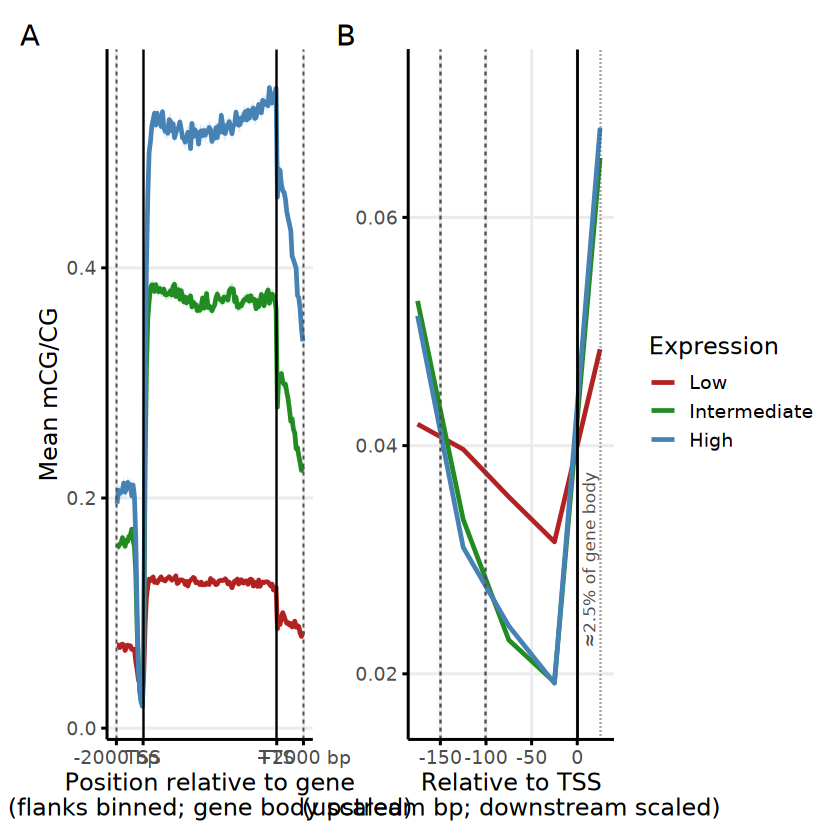

In [10]:
######################################################################
## 7. Combined Metagene Profile and Promoter Zoom Plot (Fig 2)
######################################################################

library(ggplot2)
library(dplyr)
library(patchwork)

# Assumes you have already run BLOCK 5 and BLOCK 6 and therefore have:
#   - p_metagene   (full metagene plot)
#   - promoter_zoom_df (data frame)
# And you have these parameters from BLOCK 6:
#   flank_size, nbins_flank, nbins_body, bin_width, body_scale

# --------------------------
# Panel A (metagene): reuse p_metagene, add journal-style tag handling
# --------------------------
plot_meta <- p_metagene +
  theme(
    plot.title = element_blank()  # don't use title for "A"; we'll use patchwork tags
  )

plot_meta <- p_metagene +
  guides(color = "none", fill = "none") +
  theme(
    plot.title = element_blank()
  )

# --------------------------
# Panel B (promoter zoom): rebuild from promoter_zoom_df with your finalized settings
# --------------------------
plot_promoter <- ggplot(promoter_zoom_df, aes(x = pos, y = mean_meth, color = expr_cat)) +
  geom_line(linewidth = 1) +

  # Reference lines: upstream in bp; downstream is scaled
  geom_vline(xintercept = -150, linetype = "dashed", linewidth = 0.5, color = "grey30") +
  geom_vline(xintercept = -100, linetype = "dashed", linewidth = 0.5, color = "grey30") +
  geom_vline(xintercept = 0,    linetype = "solid",  linewidth = 0.6, color = "black") +
  geom_vline(xintercept = 25,   linetype = "dotted", linewidth = 0.5, color = "grey30") +

  annotate(
    "text",
    x = 25,
    y = 0.03,
    label = "≈2.5% of gene body",
    angle = 90,
    vjust = -0.4,
    size = 3.5,
    color = "grey30"
  ) +

  coord_cartesian(xlim = c(-175, 30)) +
  scale_y_continuous(limits = c(0.017, 0.072)) +
  scale_color_manual(
    name   = "Expression",
    values = c("Low"="firebrick", "Intermediate"="forestgreen", "High"="steelblue")
  ) +
  labs(
    x = "Relative to TSS\n(upstream bp; downstream scaled)",
    y     = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title       = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line        = element_line(color = "black"),
    axis.ticks       = element_line(color = "black"),
    legend.position  = "right"
  )

# --------------------------
# Combine with patchwork tags ("A", "B") in the outer margin
# --------------------------
combined <- (plot_meta + plot_promoter) +
  plot_layout(widths = c(1, 1)) +
  plot_annotation(
    tag_levels = "A",   # gives A, B, ...
    tag_prefix = "",
    tag_suffix = "",
    theme = theme(
      plot.tag = element_text(face = "bold", size = 16),
      plot.tag.position = c(0.01, 0.99)  # top-left of each panel, outside panel content
    )
  )

combined

# Save
ggsave(
  filename = file.path(out_fig_dir, "Fig2.pdf"),
  plot     = combined,
  device   = grDevices::cairo_pdf,
  width    = 13, height = 5, units = "in",
  bg       = "white"
)

In [14]:
# Save for downstream notebooks (not committed)
dir.create(file.path("outputs", "data"), recursive = TRUE, showWarnings = FALSE)
saveRDS(df_profile, file = file.path("outputs", "data", "df_profile.rds"))

In [13]:
######################################################################
## Reproducibility
######################################################################

cat("Date:", as.character(Sys.Date()), "\n")
cat("R version:", R.version.string, "\n")
cat("Platform:", R.version$platform, "\n\n")

pkgs <- c("ggplot2","dplyr","readr","viridis","viridisLite",
          "Cairo","here","patchwork","grid")

cat("Key package versions:\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), as.character(packageVersion(p))))
  } else {
    cat(sprintf("  %-14s %s\n", paste0(p, ":"), "not installed"))
  }
}

Date: 2026-01-23 
R version: R version 4.3.3 (2024-02-29) 
Platform: x86_64-conda-linux-gnu 

Key package versions:
  ggplot2:       3.5.2
  dplyr:         1.1.4
  readr:         2.1.5
  viridis:       0.6.5
  viridisLite:   0.4.2
  Cairo:         1.6.5
  here:          1.0.2
  patchwork:     1.3.1
  grid:          4.3.3
